# Libraries

In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from scipy.stats import norm
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, classification_report)

# Data
## Import Data

In [2]:
X = np.load('data/X.npy')
y = np.load('data/Y.npy')

N, K = X.shape
print(f"Observations: {N}, Variables: {K}")

Observations: 5881, Variables: 7


In [3]:
feature_names = [
    'frequency',
    'monetary_value',
    'cancellation_rate',
    'stockcode_diversity',
    'return_propensity',
    'avg_time_between_purchases',
    'is_uk'
]

## Data Check

In [4]:
print("y dtype:", y.dtype)
print("y unique values:", np.unique(y))
print("y shape:", y.shape)
print("X shape:", X.shape)
print("X has NaN:", np.isnan(X).any())
print("y has NaN:", np.isnan(y).any())

y dtype: int32
y unique values: [0 1]
y shape: (5881,)
X shape: (5881, 7)
X has NaN: False
y has NaN: False


## Train Test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2,
    random_state = 42,
    stratify = y    # keep proportion of churn classes within test and train
)

print(f"Train: {X_train.shape[0]} observations")
print(f"Test:  {X_test.shape[0]} observations")

Train: 4704 observations
Test:  1177 observations


### Standrdization 
(fit only on train, apply it to test)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

N_Train, K = X_train.shape

# Bayesian probit Model
## Model based on train set

In [7]:
with pm.Model(coords={'features': feature_names}) as probit_model:
    
    # Non informative Prior
    beta = pm.MvNormal(
        'beta',
        mu = np.zeros(K),
        cov = 100*np.eye(K),
        shape = K,
        dims = 'features'
    )

    # Likelihood probit
    mu = pm.math.dot(X_train, beta)
    p = pm.math.invprobit(mu)
    y_obs = pm.Bernoulli('y_obs', p=p, observed = y_train)


# --- NUTS ---
print("Beginning the training...")

with probit_model:
    trace = pm.sample(
        draws = 1000, # samples after warmup
        tune = 1000, # warmup 
        chains = 4, # calibrate with Rhat !!!!!!!!
        cores = 1, # CPU cores
        target_accept = 0.95, # acceptance probability of target
        random_seed = 42, 
        return_inferencedata= True
    )

Initializing NUTS using jitter+adapt_diag...


Beginning the training...


Sequential sampling (4 chains in 1 job)
NUTS: [beta]


/Users/paolominini/Desktop/University/Bayesian 
Analysis/project/Churn_Model_Bayesian/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


## Diagnostics
### Diagnostics based on train set

                                   mean     sd  hdi_3%  hdi_97%  mcse_mean  \
beta[frequency]                  -0.362  0.054  -0.461   -0.256      0.001   
beta[monetary_value]             -0.274  0.035  -0.342   -0.209      0.001   
beta[cancellation_rate]           0.058  0.022   0.015    0.099      0.000   
beta[stockcode_diversity]        -0.389  0.041  -0.468   -0.316      0.001   
beta[return_propensity]           0.034  0.026  -0.012    0.083      0.000   
beta[avg_time_between_purchases] -0.157  0.020  -0.195   -0.120      0.000   
beta[is_uk]                       0.015  0.020  -0.026    0.051      0.000   

                                  mcse_sd  ess_bulk  ess_tail  r_hat  
beta[frequency]                     0.001    2911.0    2724.0    1.0  
beta[monetary_value]                0.001    2498.0    2754.0    1.0  
beta[cancellation_rate]             0.000    3493.0    3071.0    1.0  
beta[stockcode_diversity]           0.001    3115.0    3134.0    1.0  
beta[return_propensi

<Axes: >

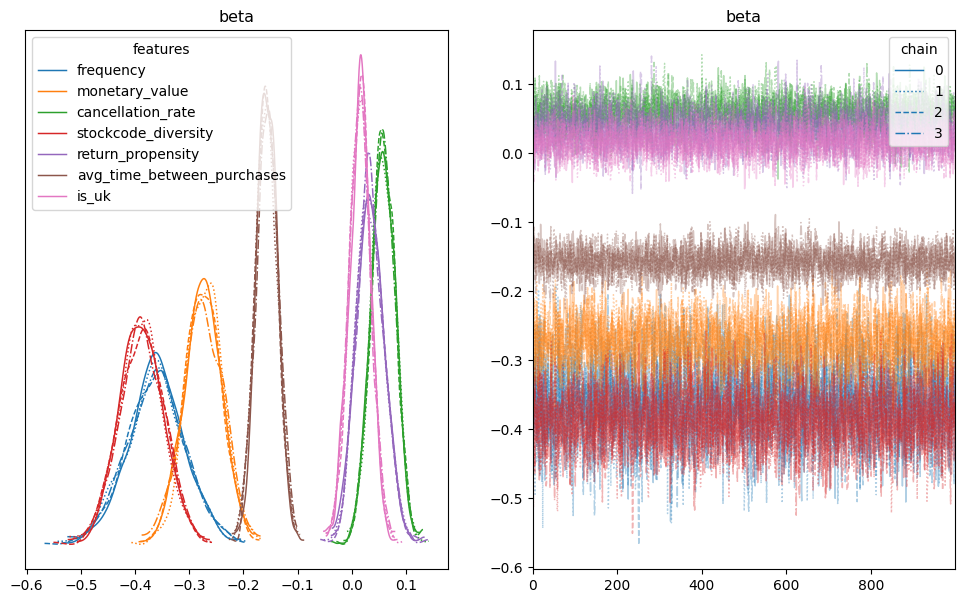

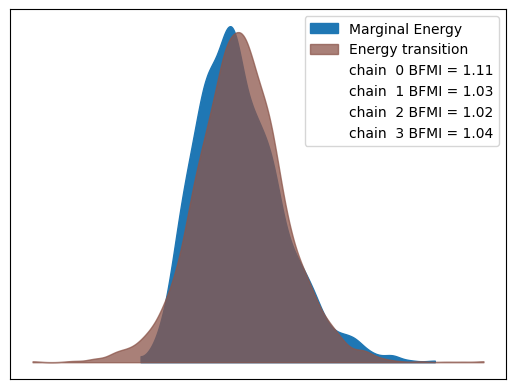

In [8]:
print(az.summary(trace, var_names = ['beta']))
print("Max R-hat:", float(az.rhat(trace)['beta'].max()))

az.plot_trace(trace, var_names = ['beta'], legend= True, figsize = (12, K))
az.plot_energy(trace)

# Predictions and Evaluation
Based on test set

In [9]:
beta_samples  = trace.posterior['beta'].values.reshape(-1, K)
lin_pred = X_test @ beta_samples.T
y_prob = norm.cdf(lin_pred).mean(axis=1)
y_class = (y_prob > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_class))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_class))
print("\nClassification Report:\n", classification_report(y_test, y_class))

Accuracy : 0.7247238742565846
ROC-AUC  : 0.7708304353873974

Confusion Matrix:
 [[352 201]
 [123 501]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.64      0.68       553
           1       0.71      0.80      0.76       624

    accuracy                           0.72      1177
   macro avg       0.73      0.72      0.72      1177
weighted avg       0.73      0.72      0.72      1177

